# documentation

Since you are using `StandardScaler` in your code, the **physical units** (Kelvin, Optical Depth, etc.) are converted into **"Standard Deviations"** before the kernel sees them.

This means we don't set the kernel size to "10 Kelvin" or "5 COD". Instead, we set it based on **how sensitive the output is to 1 Standard Deviation of change.**

Here is the logic and the tuned code.

### The Logic: Mapping Physics to "Length Scale"

Remember: **Small Length Scale = High Sensitivity (Curve changes fast).**

1.  **COD (Range 0-50):**

      * **Physics:** This is the strongest driver. A change of just 5-10 COD units causes a massive jump in reflection.
      * **Scaled Space:** Since the Standard Deviation of COD is roughly \~15, a change of 5 units is about `0.3` standard deviations.
      * **Setting:** We need a **very small length scale** (`0.3` to `0.5`) so the model can react fast to cloud changes.

2.  **Ta (Range 233-303 K):**

      * **Physics:** Temperature affects the atmosphere slowly. A change of 10K usually results in a small, smooth change in radiation (linear trend).
      * **Scaled Space:** We don't want the model to "wiggle" for every 1-2 degrees. We want it to see the big picture.
      * **Setting:** We use a **large length scale** (`2.0` to `4.0`) to force a smooth relationship.

3.  **rh (Range 0-1):**

      * **Physics:** Weakest correlation.
      * **Setting:** **Very large length scale** (`3.0`+) to prevent the model from overfitting to noise.

4.  **th0 (Range 0.5-1.0):**

      * **Physics:** The sun angle has a strong, consistent geometric effect (cosine law).
      * **Setting:** **Medium length scale** (`1.0` to `1.5`).

# start

In [6]:
import h5py
import pandas as pd
import numpy as np
h5_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.h5"
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
with h5py.File(h5_file_path, 'r') as h5_file:
    columns = [col.decode('utf-8') for col in h5_file['data/axis0'][:]]
    data = h5_file['data/block0_values'][:]
df = pd.DataFrame(data, columns=columns)
df = df[df['Ta'] >= 233]
df.to_csv(csv_file_path, index=False, encoding='utf-8')

Data split 7:3 training dataset: testing dataset

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
df = pd.read_csv(csv_file_path)
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
train_file_path = "./LUT/SWRTM_train.csv"
test_file_path = "./LUT/SWRTM_test.csv"
train_df.to_csv(train_file_path, index=False)  
test_df.to_csv(test_file_path, index=False)  


Correlation analysis

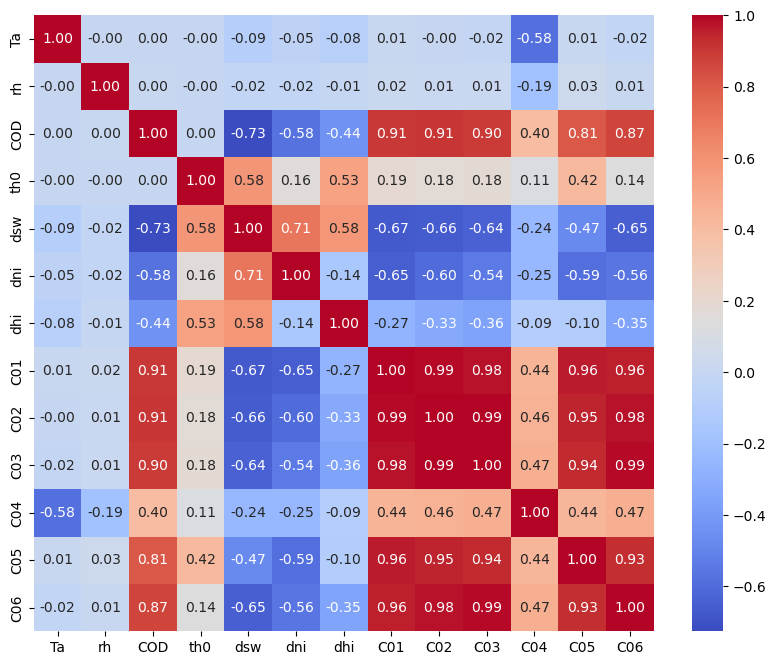

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
df = pd.read_csv(csv_file_path)
df['th0'] = np.cos(np.radians(df['th0'])) 

F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                           12.06884597258561,13.936208329862962,18.20438461023419]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
df[channels] = df[channels].div(F_dw_os_srf_channel)
correlation_matrix = df.corr()
#print(correlation_matrix)
plt.figure(figsize=(10, 8)) 
sns.heatmap(correlation_matrix, 
            annot=True,     
            fmt=".2f",      
            cmap="coolwarm", 
            cbar=True)        
plt.show()

# Gaussian Process Regression fitting using sklearn GPR model

A flexible, classical machine learning method that makes predictions based on observed patterns in your data and gives you both a predicted COD and an estimate of confidence or uncertainty for every prediction.

It tries to fit a smooth function through your data, using a mathematical structure (“kernel”) that describes how points relate to one another.

Key feature: 

- Very good for moderate-sized datasets
- Provides uncertainty estimates 

# GPR model fitting


PCA to keep the spectral feature between 6 channels.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ... (Load your data as before) ...
file_path = "./LUT/SWRTM_train.csv"
data = pd.read_csv(file_path)
#data_load = pd.read_csv(file_path)

print(f"Original Data Size: {len(data)}")
# if len(data_load) > 1500:
#     data = data_load.sample(n=1500, random_state=42).reset_index(drop=True)
#     print(">> Subsampled to 1500 rows for rapid testing.")
# else:
#     data = data_load


# process
data['th0'] = np.cos(np.radians(data['th0'])) 
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']


X = data[['Ta', 'rh', 'th0', 'COD']].values
y = data[['dsw']].values


scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y).ravel()


# --- STEP 2: TRAIN GPR ON THE COMPRESSED VECTOR ---

# 1. Kernel for the PCA components
initial_scales = [3.0, 3.0, 0.5, 0.35] # 10, 3.55, 7.06, 0.05
# ['Ta', 'rh', 'th0', 'COD']
# 1. Input Sensitivities (Length Scales) based on Heatmap
# Ta (Input 0): Impact is specific to C04, low elsewhere. 
#     -> Start HIGH (3.0) so it doesn't add noise to C01-C03.
# rh (Input 1): Similar to Ta. 
#     -> Start HIGH (3.0).
# th0 (Input 2): Moderate impact on C05 (0.42) and others.
#     -> Start MEDIUM (1.5).
# COD (Input 3): MASSIVE impact (0.91) on almost everything. 
#     -> Start LOW (0.5) so the model can react quickly to cloud changes.


# We allow COD to go very small (1e-2) because cloud physics is sharp.
# We force Ta/rh to stay above 0.1 so they don't cause overfitting.
# --- 2. Length Scale Bounds (The "Safety Limits") ---
# We define distinct limits for each variable.
# Format: (Lower_Limit, Upper_Limit)
bounds = [
    (0.5, 10.0),  # Ta: Don't let it get too wiggly (<0.5), allow it to be linear (>5)
    (0.5, 10.0),  # rh: Same as Ta
    (0.1, 5.0),   # th0: Standard geometric range
    (0.05, 2.0)   # COD: ALLOW it to be very sharp (0.05), prevent it from being lazy (>2.0)
]

# --- 3. Construct the Kernel ---
# RTM data is clean. WhiteKernel is small.
kernel = C(1.0, (1e-2, 1e3)) * \
         RBF(length_scale=initial_scales, length_scale_bounds=bounds) + \
         WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-6, 1e-3))

# Train on y_pca, not the raw y
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=0, random_state=42)


gpr.fit(X_scaled, y_scaled)

Original Data Size: 1500
>> Subsampled to 1500 rows for rapid testing.


/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,1**2 * RBF(le...e_level=1e-05)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,42
,kernel__k1,"1**2 * RBF(le...3, 0.5, 0.35])"
,kernel__k2,WhiteKernel(noise_level=1e-05)
,kernel__k1__k1,1**2


In [16]:
# WRONG (Shows what you told it to do)
print(gpr.kernel) 

# CORRECT (Shows what it learned)
print(gpr.kernel_)

1**2 * RBF(length_scale=[3, 3, 0.5, 0.35]) + WhiteKernel(noise_level=1e-05)
14.5**2 * RBF(length_scale=[10, 3.36, 5, 0.05]) + WhiteKernel(noise_level=1e-06)


In [17]:
def predict_spectrum(new_X_raw):
    """
    Input: Array of shape (N, 4) -> [Ta, rh, th0, COD]
    Output: Array of shape (N, 6) -> [C01 ... C06]
    """
    # A. Scale Input (Using the loaded scaler)
    X_new_scaled = scaler_X.transform(new_X_raw)
    
    # B. Predict PCA components (Using the loaded GPR)
    y_pred_scaled = gpr.predict(X_new_scaled)    
    
    # D. Inverse Scale (Get back to physical units)
    y_pred_final = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

    
    return y_pred_final
# Test with the first 5 rows of training data
test_prediction = predict_spectrum(X[:500])
metrics = evaluate_rtm_performance(y[:500], test_prediction, channels)

# 2. See the plots
plot_scatter_validation(y[:500], test_prediction)

NameError: name 'X' is not defined

### Model save

In [49]:
import joblib
import os

# 1. Create a dictionary containing all components
model_bundle = {
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'gpr_model': gpr,
    'metadata': {
        'description': 'SWRTM Emulator with GPR',
        'date': '2025-11-24',
        'input_columns': ['Ta', 'rh', 'th0', 'COD'],
        'output_channels': ['dsw']
    }
}

# 2. Define save path
save_dir = "./GUI/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    
save_path = os.path.join(save_dir, "SWRTM_ghi_GPR_v0.pkl")

# 3. Save to disk
joblib.dump(model_bundle, save_path)

print(f"Model pipeline successfully saved to: {save_path}")

Model pipeline successfully saved to: ./GUI/SWRTM_ghi_GPR_v0.pkl


# results validation

### model loading

In [7]:
import joblib
import numpy as np

# 1. Load the bundle
model_path = "./GUI/SWRTM_ghi_GPR_v0.pkl"
print(f"Loading model from {model_path}...")

loaded_bundle = joblib.load(model_path)

# 2. Extract the components back into variables
scaler_X = loaded_bundle['scaler_X']
scaler_y = loaded_bundle['scaler_y']
gpr      = loaded_bundle['gpr_model']

print("Model loaded successfully!")

# 3. Re-define the prediction function using these loaded objects
def predict_spectrum(new_X_raw):
    """
    Input: Array of shape (N, 4) -> [Ta, rh, th0, COD]
    Output: Array of shape (N, 6) -> [C01 ... C06]
    """
    # A. Scale Input (Using the loaded scaler)
    X_new_scaled = scaler_X.transform(new_X_raw)
    
    # B. Predict PCA components (Using the loaded GPR)
    y_pred_scaled = gpr.predict(X_new_scaled)

    
    # D. Inverse Scale (Get back to physical units)
    y_pred_final = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

    
    return y_pred_final


# --- TEST IT ---
# Example input: Ta=290K, rh=0.5, th0=0.8, COD=10
file_path = "./LUT/SWRTM_test.csv"
data_test = pd.read_csv(file_path)
data_test['th0'] = np.cos(np.radians(data_test['th0'])) 

X_test = data_test[['Ta', 'rh', 'th0', 'COD']].values
y_test = data_test[['dsw']].values

y_pred = predict_spectrum(X_test)

Loading model from ./GUI/SWRTM_ghi_GPR_v0.pkl...
Model loaded successfully!


=== Model Evaluation Metrics ===
         RMSE (Abs)  MAE (Abs)  rRMSE (%)  R2 Score
0            1.7841     1.0913     0.2665       1.0
AVERAGE      1.7841     1.0913     0.2665       1.0


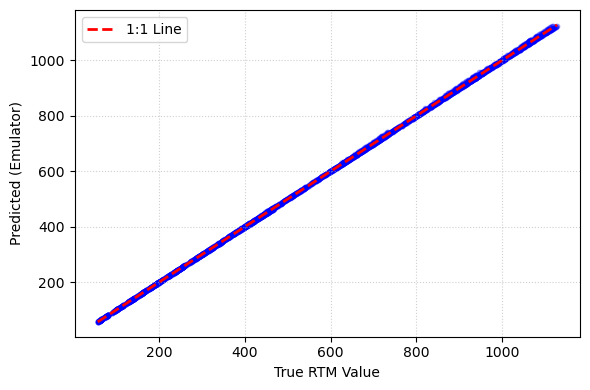

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def evaluate_rtm_performance(y_test, y_pred, channel_names=None):
    
    
    # --- 1. Calculate Metrics ---
    
    # RMSE (Root Mean Squared Error) - Sensitive to large errors
    rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values'))
    
    # MAE (Mean Absolute Error) - More robust to outliers
    mae_per_channel = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    
    # R2 Score - How well the trend is captured (1.0 is perfect)
    r2_per_channel = r2_score(y_test, y_pred, multioutput='raw_values')
    
    # Relative RMSE (Percentage Error)
    # We add a small epsilon (1e-6) to avoid division by zero if y_test has 0s
    # Formula: sqrt(mean(((y_pred - y_test) / y_test)^2)) * 100
    relative_errors = (y_pred - y_test) / (y_test + 1e-6)
    rrmse_per_channel = np.sqrt(np.mean(relative_errors**2, axis=0)) * 100

    # --- 2. Create a Summary Table ---
    metrics_df = pd.DataFrame({
        'RMSE (Abs)': rmse,
        'MAE (Abs)': mae_per_channel,
        'rRMSE (%)': rrmse_per_channel,
        'R2 Score': r2_per_channel
    }, index=channel_names)
    
    # Add an "Average" row at the bottom
    metrics_df.loc['AVERAGE'] = metrics_df.mean()
    
    print("=== Model Evaluation Metrics ===")
    print(metrics_df.round(4))
    
    return metrics_df

# --- 3. Visualization Function (Crucial for RTM Papers) ---
def plot_scatter_validation(y_test, y_pred):
    fig, ax = plt.subplots(1, 1, figsize=(6, 4)) # 2 rows, 3 columns for 6 channels
    #axes = axes.ravel()
    
    for i in range(1):
        # Get data for this channel
        true = y_test[:, i]
        pred = y_pred[:, i]
        
        # Calculate nice limits
        min_val = min(true.min(), pred.min())
        max_val = max(true.max(), pred.max())
        
        
        # Scatter plot
        ax.scatter(true, pred, alpha=0.3, s=10, color='blue')
        
        # 1:1 line (Perfect prediction)
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')
        
        #ax.set_title(f"{channel_names[i]} Validation")
        ax.set_xlabel("True RTM Value")
        ax.set_ylabel("Predicted (Emulator)")
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# === RUN IT ===
#channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']

# 1. Get the numbers
metrics = evaluate_rtm_performance(y_test, y_pred)

# 2. See the plots
plot_scatter_validation(y_test, y_pred)

# more test·

In [2]:
import joblib
import numpy as np
import pandas as pd

# 1. Load the bundle
model_path = "./GUI/SWRTM_ghi_GPR_v0.pkl"
print(f"Loading model from {model_path}...")

loaded_bundle = joblib.load(model_path)

# 2. Extract the components back into variables
scaler_X = loaded_bundle['scaler_X']
scaler_y = loaded_bundle['scaler_y']
gpr      = loaded_bundle['gpr_model']

print("Model loaded successfully!")

# 3. Re-define the prediction function using these loaded objects
def predict_spectrum(new_X_raw):
    """
    Input: Array of shape (N, 4) -> [Ta, rh, th0, COD]
    Output: Array of shape (N, 6) -> [C01 ... C06]
    """
    # A. Scale Input (Using the loaded scaler)
    X_new_scaled = scaler_X.transform(new_X_raw)
    
    # B. Predict PCA components (Using the loaded GPR)
    y_pred_scaled = gpr.predict(X_new_scaled)

    
    # D. Inverse Scale (Get back to physical units)
    y_pred_final = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

    
    return y_pred_final


# --- TEST IT ---
# Example input: Ta=290K, rh=0.5, th0=0.8, COD=10
file_path = "./LUT/SWRTM_test.csv"
data_test = pd.read_csv(file_path)
data_test['th0'] = np.cos(np.radians(data_test['th0'])) 

X_test = data_test[['Ta', 'rh', 'th0', 'COD']].values
y_test = data_test[['dsw']].values

y_pred = predict_spectrum(X_test)

Loading model from ./GUI/SWRTM_ghi_GPR_v0.pkl...
Model loaded successfully!


=== Model Evaluation Metrics ===
         RMSE (Abs)  MAE (Abs)  rRMSE (%)  R2 Score
0             0.213     0.1598     0.0515       1.0
AVERAGE       0.213     0.1598     0.0515       1.0


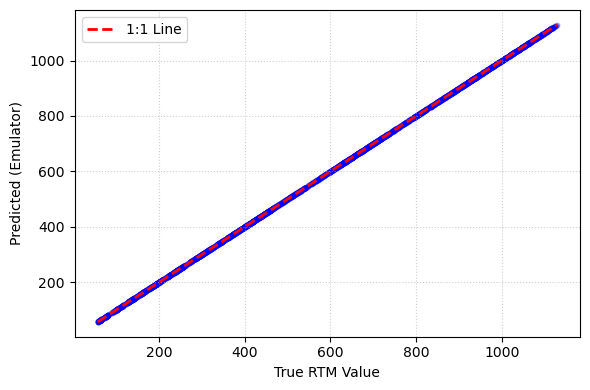

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def evaluate_rtm_performance(y_test, y_pred, channel_names=None):
    
    
    # --- 1. Calculate Metrics ---
    
    # RMSE (Root Mean Squared Error) - Sensitive to large errors
    rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values'))
    
    # MAE (Mean Absolute Error) - More robust to outliers
    mae_per_channel = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    
    # R2 Score - How well the trend is captured (1.0 is perfect)
    r2_per_channel = r2_score(y_test, y_pred, multioutput='raw_values')
    
    # Relative RMSE (Percentage Error)
    # We add a small epsilon (1e-6) to avoid division by zero if y_test has 0s
    # Formula: sqrt(mean(((y_pred - y_test) / y_test)^2)) * 100
    relative_errors = (y_pred - y_test) / (y_test + 1e-6)
    rrmse_per_channel = np.sqrt(np.mean(relative_errors**2, axis=0)) * 100

    # --- 2. Create a Summary Table ---
    metrics_df = pd.DataFrame({
        'RMSE (Abs)': rmse,
        'MAE (Abs)': mae_per_channel,
        'rRMSE (%)': rrmse_per_channel,
        'R2 Score': r2_per_channel
    }, index=channel_names)
    
    # Add an "Average" row at the bottom
    metrics_df.loc['AVERAGE'] = metrics_df.mean()
    
    print("=== Model Evaluation Metrics ===")
    print(metrics_df.round(4))
    
    return metrics_df

# --- 3. Visualization Function (Crucial for RTM Papers) ---
def plot_scatter_validation(y_test, y_pred):
    fig, ax = plt.subplots(1, 1, figsize=(6, 4)) # 2 rows, 3 columns for 6 channels
    #axes = axes.ravel()
    
    for i in range(1):
        # Get data for this channel
        true = y_test[:, i]
        pred = y_pred[:, i]
        
        # Calculate nice limits
        min_val = min(true.min(), pred.min())
        max_val = max(true.max(), pred.max())
        
        
        # Scatter plot
        ax.scatter(true, pred, alpha=0.3, s=10, color='blue')
        
        # 1:1 line (Perfect prediction)
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')
        
        #ax.set_title(f"{channel_names[i]} Validation")
        ax.set_xlabel("True RTM Value")
        ax.set_ylabel("Predicted (Emulator)")
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# === RUN IT ===
#channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']

# 1. Get the numbers
metrics = evaluate_rtm_performance(y_test, y_pred)

# 2. See the plots
plot_scatter_validation(y_test, y_pred)

In [11]:
273.15 

T_deltas = np.arange(-30, 30 + 5, 5, dtype="float")
T_surf_v = T_deltas + 273.15
T_surf_v

array([243.15, 248.15, 253.15, 258.15, 263.15, 268.15, 273.15, 278.15,
       283.15, 288.15, 293.15, 298.15, 303.15])

In [15]:
T_deltas = np.arange(-50, 10 + 5, 10, dtype="float")
T_surf_v = T_deltas + 294.2
T_surf_v

array([244.2, 254.2, 264.2, 274.2, 284.2, 294.2, 304.2])

In [19]:
COD_v = [0]
CODs = 10 ** np.arange(-1.0, 2.0 + 0.2, 0.2)   # 0.1 to 100
COD_v += CODs[CODs <= 50].tolist()  # 0 to 10
COD_v

[0,
 0.1,
 0.15848931924611134,
 0.25118864315095796,
 0.39810717055349715,
 0.630957344480193,
 0.9999999999999994,
 1.5848931924611125,
 2.5118864315095784,
 3.981071705534969,
 6.309573444801926,
 9.99999999999999,
 15.848931924611117,
 25.11886431509577,
 39.81071705534967]